In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

# Drop 2020
df_model = df.dropna(subset=["race_group", "age_group", "sex",
                               "education", "income_group", "obese"]).copy()

# Encode
le_state = LabelEncoder()
df_model["state_code"] = le_state.fit_transform(df_model["_STATE"])

df_encoded = pd.get_dummies(df_model[["age_group", "sex", "education", 
                                       "income_group", "race_group"]], drop_first=True)
state_dummies = pd.get_dummies(df_model["state_code"], prefix="state", drop_first=True)
X = pd.concat([df_encoded, state_dummies], axis=1)
y = df_model["obese"].values
w = df_model["_LLCPWT_adjusted"].values

print("Shape:", X.shape)
print("Fitting logistic regression...")

lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X, y, sample_weight=w)

print("Done.")
print(f"Training AUC reference: 0.6354")

Shape: (1322240, 81)
Fitting logistic regression...
Done.
Training AUC reference: 0.6354


In [2]:
# Get coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_[0],
    "abs_coefficient": np.abs(lr.coef_[0])
})

# Assign groups
def get_group(feature):
    if feature.startswith("age_group"):
        return "Age"
    elif feature.startswith("sex"):
        return "Sex"
    elif feature.startswith("education"):
        return "Education"
    elif feature.startswith("income_group"):
        return "Income"
    elif feature.startswith("race_group"):
        return "Race"
    elif feature.startswith("state"):
        return "State"
    else:
        return "Other"

coef_df["group"] = coef_df["feature"].apply(get_group)

# Grouped importance
group_importance = (
    coef_df.groupby("group")["abs_coefficient"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
group_importance.columns = ["Feature Group", "Summed |Coefficient|"]

print("=== GROUPED FEATURE IMPORTANCE ===")
print(group_importance.to_string(index=False))

# Individual top features excluding state
top_features = (
    coef_df[coef_df["group"] != "State"]
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
)

print("\n=== TOP 20 INDIVIDUAL FEATURES (excluding state) ===")
print(top_features[["feature", "coefficient", "abs_coefficient"]].round(4).to_string(index=False))

=== GROUPED FEATURE IMPORTANCE ===
Feature Group  Summed |Coefficient|
          Age              9.909460
        State              5.427836
         Race              1.738484
       Income              0.959419
    Education              0.402694
          Sex              0.087249

=== TOP 20 INDIVIDUAL FEATURES (excluding state) ===
                                        feature  coefficient  abs_coefficient
                               race_group_Asian      -1.1734           1.1734
                                age_group_50-54       1.1397           1.1397
                                age_group_45-49       1.1189           1.1189
                                age_group_55-59       1.0591           1.0591
                                age_group_40-44       1.0315           1.0315
                                age_group_60-64       0.9652           0.9652
                                age_group_35-39       0.9466           0.9466
                                age

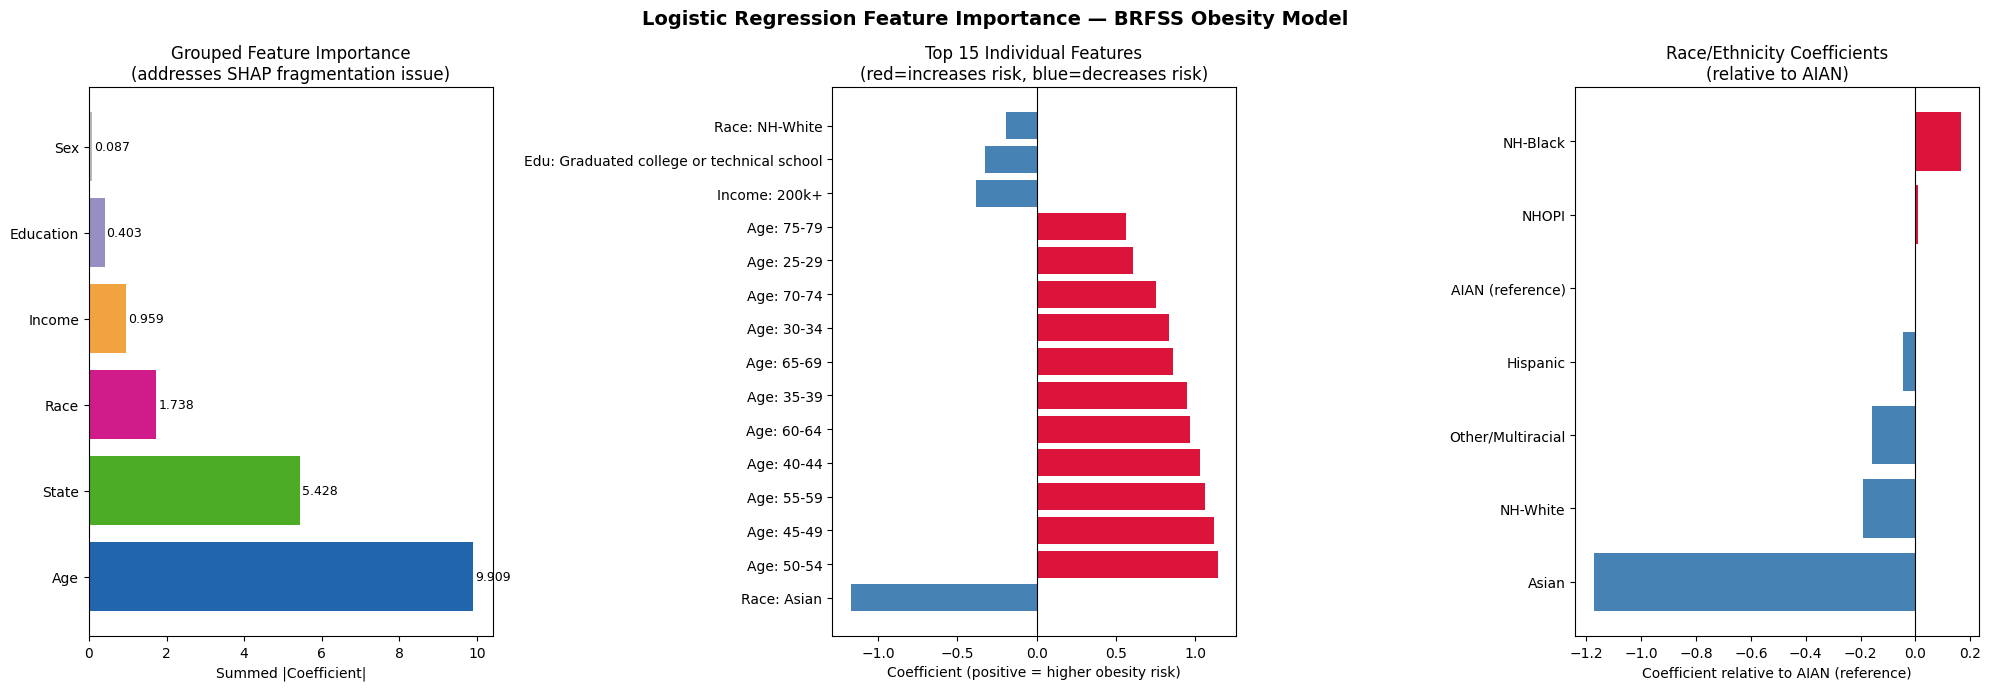

saved brfss_feature_importance_plots.png
saved brfss_feature_importance.csv
saved brfss_group_importance.csv


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Logistic Regression Feature Importance — BRFSS Obesity Model", 
             fontsize=14, fontweight="bold")

# Plot 1 — Grouped importance
ax = axes[0]
colors = ["#2166ac", "#4dac26", "#d01c8b", "#f1a340", "#998ec3", "#bababa"]
bars = ax.barh(
    group_importance["Feature Group"],
    group_importance["Summed |Coefficient|"],
    color=colors[:len(group_importance)]
)
ax.set_xlabel("Summed |Coefficient|")
ax.set_title("Grouped Feature Importance\n(addresses SHAP fragmentation issue)")
for bar, val in zip(bars, group_importance["Summed |Coefficient|"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va="center", fontsize=9)

# Plot 2 — Top individual features
ax = axes[1]
top_demo = coef_df[coef_df["group"] != "State"].sort_values(
    "abs_coefficient", ascending=False).head(15)
colors_ind = ["crimson" if c > 0 else "steelblue" for c in top_demo["coefficient"]]
ax.barh(top_demo["feature"].str.replace("race_group_", "Race: ")
        .str.replace("age_group_", "Age: ")
        .str.replace("income_group_", "Income: ")
        .str.replace("education_", "Edu: ")
        .str.replace("sex_", "Sex: "),
        top_demo["coefficient"],
        color=colors_ind)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (positive = higher obesity risk)")
ax.set_title("Top 15 Individual Features\n(red=increases risk, blue=decreases risk)")

# Plot 3 — Race coefficients specifically
ax = axes[2]
race_coefs = coef_df[coef_df["group"] == "Race"].copy()

# Add reference category
reference = pd.DataFrame({
    "feature": ["race_group_AIAN (reference)"],
    "coefficient": [0.0],
    "abs_coefficient": [0.0],
    "group": ["Race"]
})
race_coefs = pd.concat([race_coefs, reference], ignore_index=True)
race_coefs = race_coefs.sort_values("coefficient", ascending=True)

colors_race = ["steelblue" if c <= 0 else "crimson" for c in race_coefs["coefficient"]]
ax.barh(
    race_coefs["feature"].str.replace("race_group_", ""),
    race_coefs["coefficient"],
    color=colors_race
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient relative to AIAN (reference)")
ax.set_title("Race/Ethnicity Coefficients\n(relative to AIAN)")

plt.tight_layout()
plt.savefig("brfss_feature_importance_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_feature_importance_plots.png")

# Save
coef_df.to_csv("brfss_feature_importance.csv", index=False)
group_importance.to_csv("brfss_group_importance.csv", index=False)
print("saved brfss_feature_importance.csv")
print("saved brfss_group_importance.csv")

## Feature Importance Analysis — Logistic Regression

### Method
Coefficients extracted from weighted logistic regression trained on 1,322,240
individual BRFSS records (2021–2024) with state fixed effects and `_LLCPWT_adjusted`
weights. Features grouped by demographic category and summed absolute coefficients
to compute group-level importance — this addresses the SHAP fragmentation issue
where one-hot encoding splits each demographic group into multiple binary columns,
understating true group-level importance.

### Grouped Feature Importance

| Feature Group | Summed Abs Coefficient | Rank |
|---------------|------------------------|------|
| Age | 9.909 | 1 |
| State | 5.428 | 2 |
| Race | 1.738 | 3 |
| Income | 0.959 | 4 |
| Education | 0.403 | 5 |
| Sex | 0.087 | 6 |

### Key Findings

**Age is the dominant predictor.**
Summed absolute coefficient of 9.91 — more than five times the next largest
demographic group. Middle age groups (40–54) carry the largest positive
coefficients, consistent with the inverted U shape observed in trend analysis.

**State geographic variation is the second strongest signal.**
Summed absolute coefficient of 5.43 — confirming that geography captures
meaningful variation beyond demographics alone. This justifies state fixed
effects in the model.

**Race ranks third when properly grouped.**
Summed absolute coefficient of 1.74. When SHAP assigns importance to each
race dummy individually, race appears weak. Summing across all dummies
reveals race is actually the third strongest demographic predictor — stronger
than income and education.

**Asian identity is the single largest individual coefficient (-1.17).**
Larger in absolute value than any individual age group coefficient. Being
Asian reduces predicted obesity probability more than any other single
demographic characteristic in the model.

**NH-Black has the highest positive race coefficient relative to AIAN.**
Consistent with the 42.9% observed obesity rate for NH-Black respondents
in 2024 — the highest of any racial group.

**Income and education show expected gradients.**
Higher income (200k+) and college graduation both carry negative
coefficients — protective against obesity, consistent with trend analysis.

**Sex has minimal independent predictive power (0.087).**
After controlling for age, race, income, and education, sex adds little
additional signal. The observed sex difference in raw rates is largely
explained by other demographic factors.